Group Project 1: Estimation of Demand Function for Train Travel

Goal: Estimate demand function of train travel by using data on train ticket sales at a particular train station.

Data Features
num_seats_total         - Number of seats sold for the ticket
mean_net_ticket_price   - Average price of a ticket
Dept_Date               - Train departure date
Purchase_Date           - Date the train ticket was purchased
Train_Number_All        - Train number/name (masked)
Culmulative_sales       - Cumulative ticket sales at end of day
isNormCabin             - 1 if the ticket is normal cabin, 0 if the ticket is for special cabin
isReturn                - 1 if ticket corresponds to the return part of the trip
isOneway                - 1 if the ticket corresponds to a one way ticket (no return trip)
Customer_Cat            - Customer segmentation done by the provider

In [7]:
# Read in and import libraries
import pandas as pd
import numpy as np
import os
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import calendar
import seaborn as sns

# check current directory
print("Current working directory:", os.getcwd())

# # change directory to read in dataset
# os.chdir("C:/Users/User/OneDrive/Documents/NUS MSBA/Yr 1 Sem 1/DBA5101 Analytics in Managerial Economics/Assignments/Project 1")

# Read in dataset
df = pd.read_csv("data.csv")

Current working directory: /Users/ying-jeanne/Workspace/managerial/causality


In [8]:
# Explore data set
print(df.shape)
print(df.dtypes)
print(df.head(5))
df.info()

# Numeric summary
print(df.describe(include='number').T)

# Categorical summary
print(df.describe(include='object').T)

# Missingness table
missing_tbl = (
    pd.DataFrame({
        "column": df.columns,
        "missing": df.isna().sum().values,
    })
    .assign(pct_missing=lambda x: x["missing"] / len(df) * 100)
    .sort_values("pct_missing", ascending = False)
)

print(missing_tbl.to_string(index=False)) # no missing values

(209697, 10)
num_seats_total            int64
mean_net_ticket_price    float64
Dept_Date                 object
Purchase_Date             object
Train_Number_All          object
Culmulative_sales          int64
isNormCabin                int64
isReturn                   int64
isOneway                   int64
Customer_Cat              object
dtype: object
   num_seats_total  mean_net_ticket_price Dept_Date Purchase_Date  \
0                1             188.663422   10/9/19      10/10/18   
1                1             358.428869   5/27/19        6/6/18   
2                1             356.372684   5/31/20       6/17/19   
3                1             396.370505  12/10/19      12/27/18   
4                1             364.264552   5/31/20       6/19/19   

  Train_Number_All  Culmulative_sales  isNormCabin  isReturn  isOneway  \
0                A                  1            1         0         0   
1                B                  1            0         1         0   
2     

In [9]:
# Dates
for c in ["Dept_Date", "Purchase_Date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

df["Dept_Date"] = pd.to_datetime(df["Dept_Date"], errors="coerce")
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"], errors="coerce")

# Warning on format. Therefore create day, month, year columns to counter check
# Month variable can also be used for seasonality check
df["Dept_Day"] = df["Dept_Date"].dt.day
df["Purchase_Day"] = df["Purchase_Date"].dt.day

df["Dept_Month"] = df["Dept_Date"].dt.month
df["Purchase_Month"] = df["Purchase_Date"].dt.month

df["Dept_Year"] = df["Dept_Date"].dt.year
df["Purchase_Year"] = df["Purchase_Date"].dt.year

# dates look ok except that purchase year consists of only 2018 and 2019 but departure year has 2018, 2019 and 2020. 
# could be data cut-off issue
print("Unique Dept_Day values:", np.sort(df["Dept_Day"].unique()))
print("Unique Dept_Month values:", np.sort(df["Dept_Month"].unique()))
print("Unique Dept_Year values:", np.sort(df["Dept_Year"].unique()))

print("Unique Purchase_Day values:", np.sort(df["Purchase_Day"].unique()))
print("Unique Purchase_Month values:", np.sort(df["Purchase_Month"].unique()))
print("Unique Purchase_Year values:", np.sort(df["Purchase_Year"].unique()))

# Derive additional variables
df["days_in_advance"] = (df["Dept_Date"] - df["Purchase_Date"]).dt.days
df["dep_weekday"] = df["Dept_Date"].dt.weekday
df["dep_is_weekend"] = df["dep_weekday"].isin([5,6]).astype(int)


# check if there are any purchase dates after dept dates
print(df[df["days_in_advance"] < 0][["Dept_Date", "Purchase_Date", "days_in_advance"]])
print("Number of negative days_in_advance:", (df["days_in_advance"] < 0).sum())

# Safe logs
def safe_log(s):
    s = pd.to_numeric(s, errors="coerce")
    s = s.where(s > 0)
    return np.log(s)

df["ln_Q"] = safe_log(df["num_seats_total"])
df["ln_P"] = safe_log(df["mean_net_ticket_price"])


/var/folders/7x/yhw3mdn55nb4mt_qj8_jpp4r0000gn/T/ipykernel_75359/2222461336.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors="coerce")
/var/folders/7x/yhw3mdn55nb4mt_qj8_jpp4r0000gn/T/ipykernel_75359/2222461336.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors="coerce")


Unique Dept_Day values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
Unique Dept_Month values: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Unique Dept_Year values: [2018 2019 2020]
Unique Purchase_Day values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
Unique Purchase_Month values: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Unique Purchase_Year values: [2018 2019]
Empty DataFrame
Columns: [Dept_Date, Purchase_Date, days_in_advance]
Index: []
Number of negative days_in_advance: 0


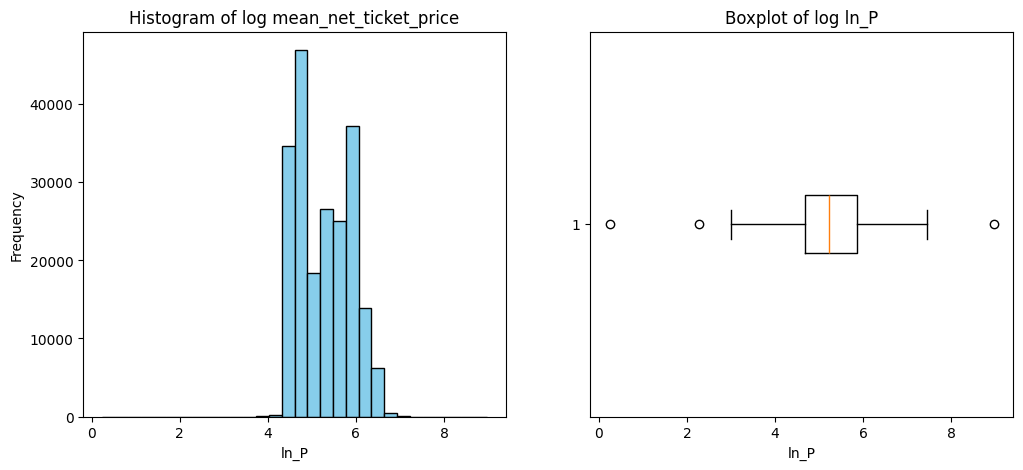

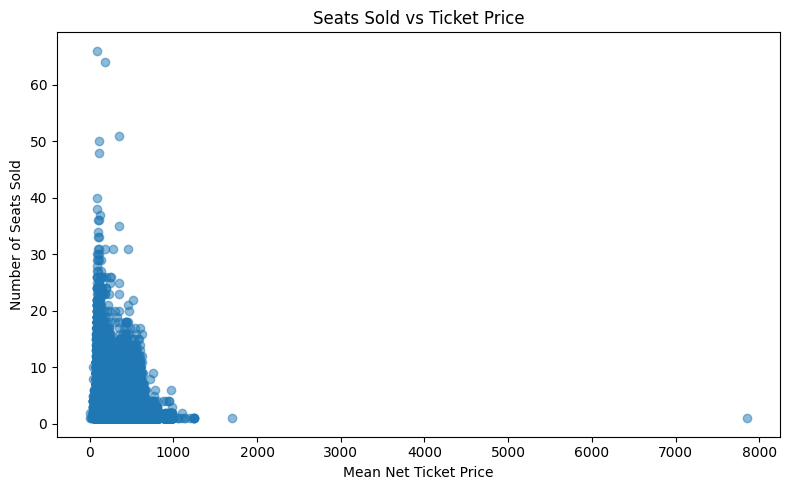

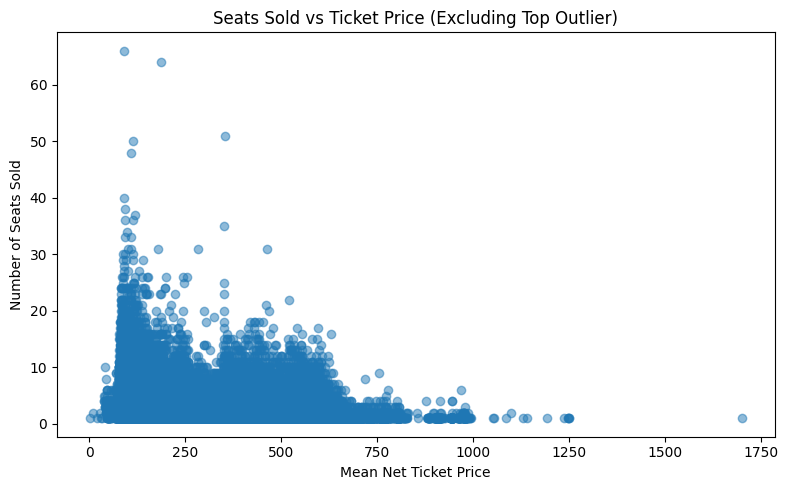

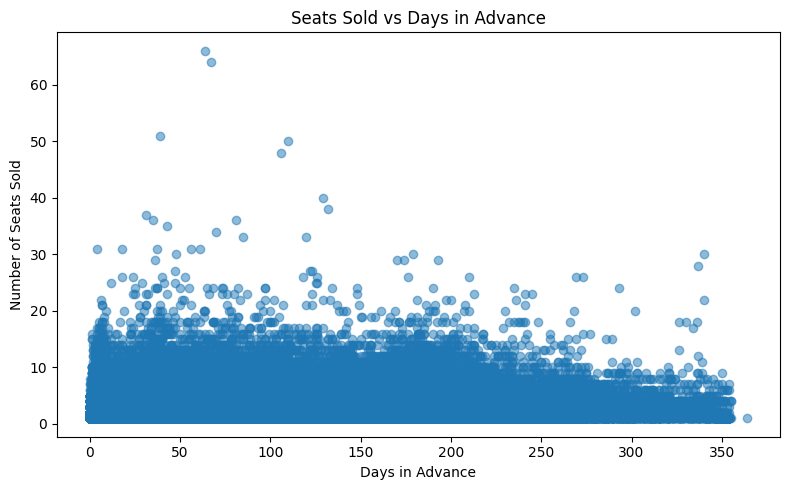

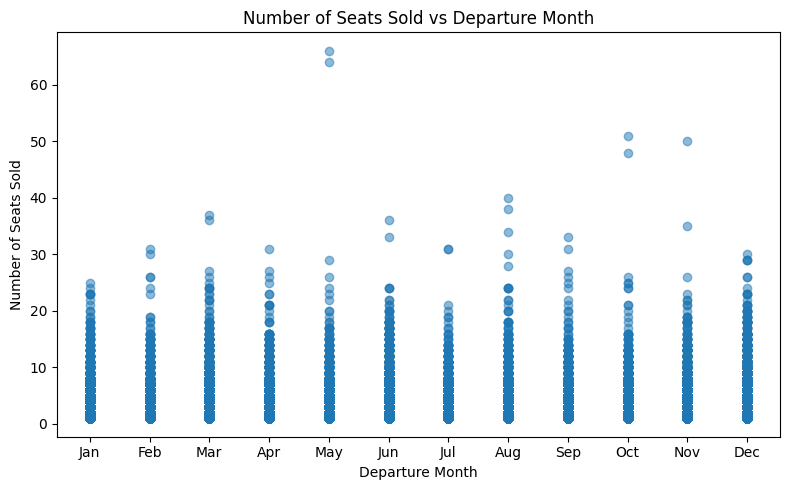

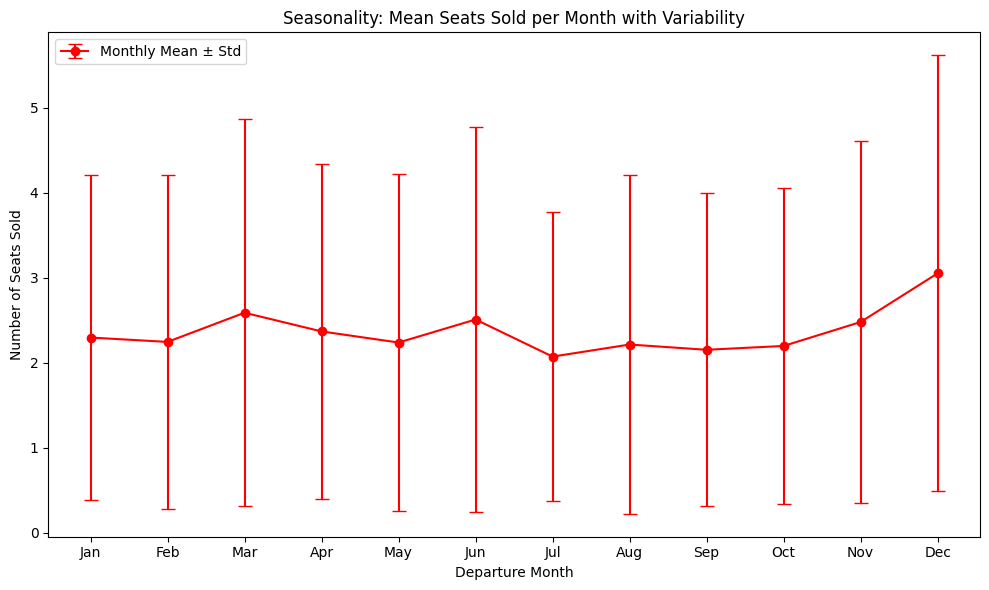

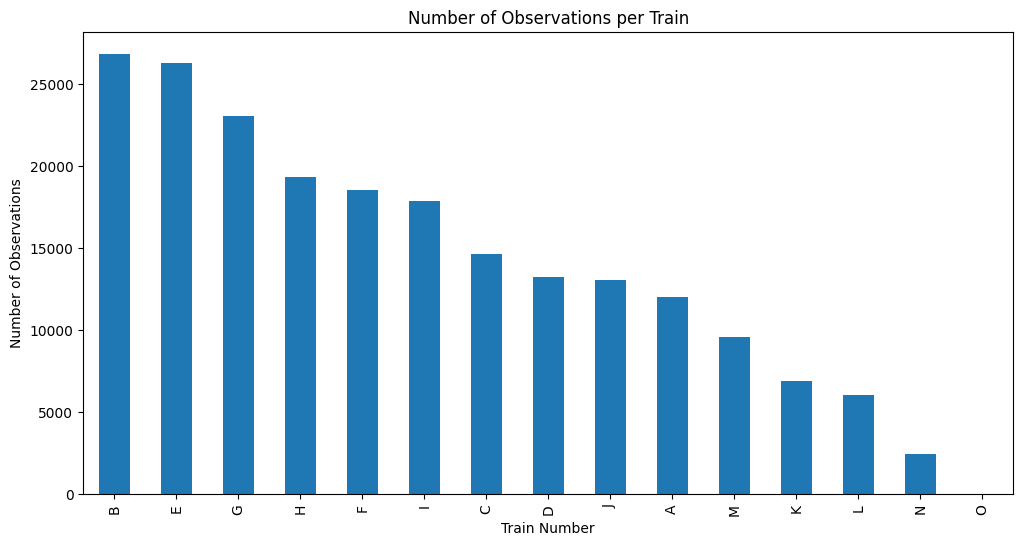

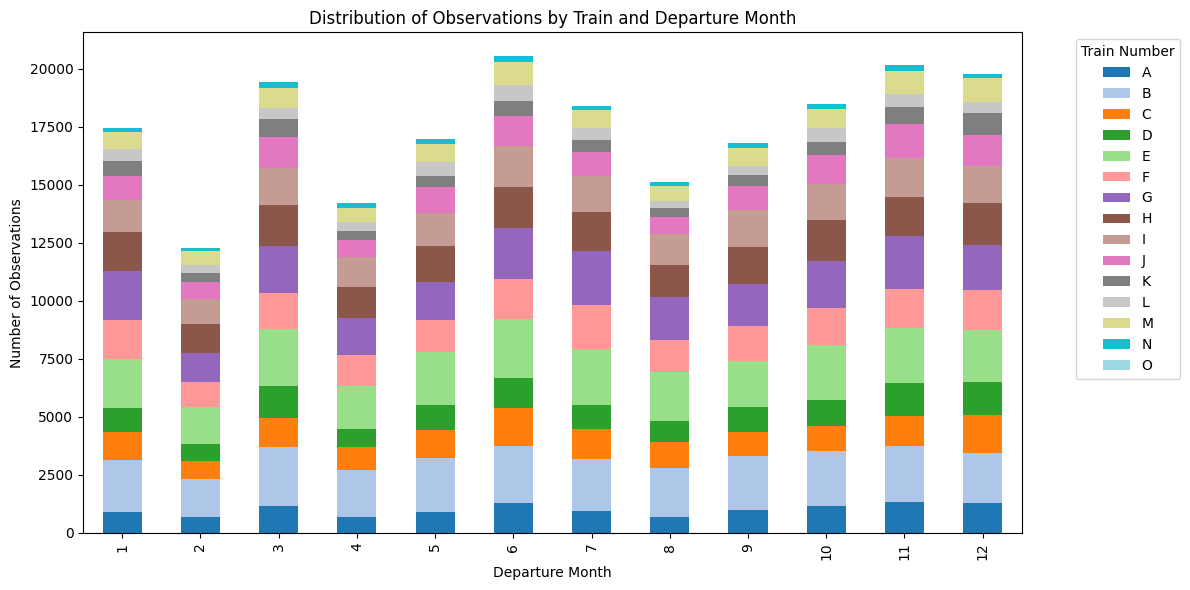

In [10]:
# Data Observations

# Visualize distribution of mean_net_ticket_price
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df["ln_P"], bins=30, color='skyblue', edgecolor='black')
plt.title("Histogram of log mean_net_ticket_price")
plt.xlabel("ln_P")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.boxplot(df["ln_P"].dropna(), vert=False)
plt.title("Boxplot of log ln_P")
plt.xlabel("ln_P")


# final plots used
plt.figure(figsize=(8, 5))
plt.scatter(df["mean_net_ticket_price"], df["num_seats_total"], alpha=0.5)
plt.xlabel("Mean Net Ticket Price")
plt.ylabel("Number of Seats Sold")
plt.title("Seats Sold vs Ticket Price")
plt.tight_layout()
plt.show()

# Exclude the top outlier in price
df_no_outlier = df[df["mean_net_ticket_price"] < df["mean_net_ticket_price"].max()]
plt.figure(figsize=(8, 5))
plt.scatter(df_no_outlier["mean_net_ticket_price"], df_no_outlier["num_seats_total"], alpha=0.5)
plt.xlabel("Mean Net Ticket Price")
plt.ylabel("Number of Seats Sold")
plt.title("Seats Sold vs Ticket Price (Excluding Top Outlier)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["days_in_advance"], df["num_seats_total"], alpha=0.5)
plt.xlabel("Days in Advance")
plt.ylabel("Number of Seats Sold")
plt.title("Seats Sold vs Days in Advance")
plt.tight_layout()
plt.show()

# Seasonality check using Dept_Month
# 1) Convert to month abbreviation Jan, Feb, ..., Dec
months_num = pd.to_numeric(df["Dept_Month"], errors="coerce")
month_labels = months_num.map(
    lambda m: calendar.month_abbr[int(m)] if pd.notna(m) and 1 <= int(m) <= 12 else pd.NA
)

# 2) Make an ordered categorical Jan..Dec
month_abbrs = [calendar.month_abbr[m] for m in range(1, 13)]
month_cat = pd.Categorical(month_labels, categories=month_abbrs, ordered=True)

# 3) Plot using the categorical codes, and relabel ticks
x_codes = month_cat.codes                      # -1 for NA
mask = x_codes != -1                           # drop NA rows

plt.figure(figsize=(8, 5))
plt.scatter(x_codes[mask], df.loc[mask, "num_seats_total"], alpha=0.5)
plt.xticks(range(len(month_abbrs)), month_abbrs)
plt.xlabel("Departure Month")
plt.ylabel("Number of Seats Sold")
plt.title("Number of Seats Sold vs Departure Month")
plt.tight_layout()
plt.show()

# Calculate mean and std for each month
monthly_stats = df.groupby("Dept_Month")["num_seats_total"].agg(['mean', 'std'])
months = monthly_stats.index
month_names = [calendar.month_abbr[m] for m in months]

plt.figure(figsize=(10, 6))
plt.errorbar(month_names, monthly_stats['mean'], yerr=monthly_stats['std'], fmt='-o', capsize=5, color='red', label='Monthly Mean ± Std')
plt.xlabel("Departure Month")
plt.ylabel("Number of Seats Sold")
plt.title("Seasonality: Mean Seats Sold per Month with Variability")
plt.legend()
plt.tight_layout()
plt.show()

# Check Clustering by train

df.groupby("Train_Number_All").size().describe()

train_counts = df.groupby("Train_Number_All").size()
train_counts = train_counts.sort_values(ascending=False)
plt.figure(figsize=(12,6))
train_counts.plot(kind="bar")
plt.title("Number of Observations per Train")
plt.xlabel("Train Number")
plt.ylabel("Number of Observations")
plt.xticks(rotation=90)  # rotate labels if there are many trains
plt.show()

# Count number of observations for each train in each month
train_month_counts = (
    df.groupby([df["Dept_Date"].dt.month, "Train_Number_All"])
      .size()
      .reset_index(name="count")
)

# Pivot so months are x-axis, trains are stacked segments
pivot = train_month_counts.pivot(index="Dept_Date", 
                                 columns="Train_Number_All", 
                                 values="count").fillna(0)

# Plot stacked bar of observations by month and train
pivot.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")

plt.title("Distribution of Observations by Train and Departure Month")
plt.xlabel("Departure Month")
plt.ylabel("Number of Observations")
plt.legend(title="Train Number", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

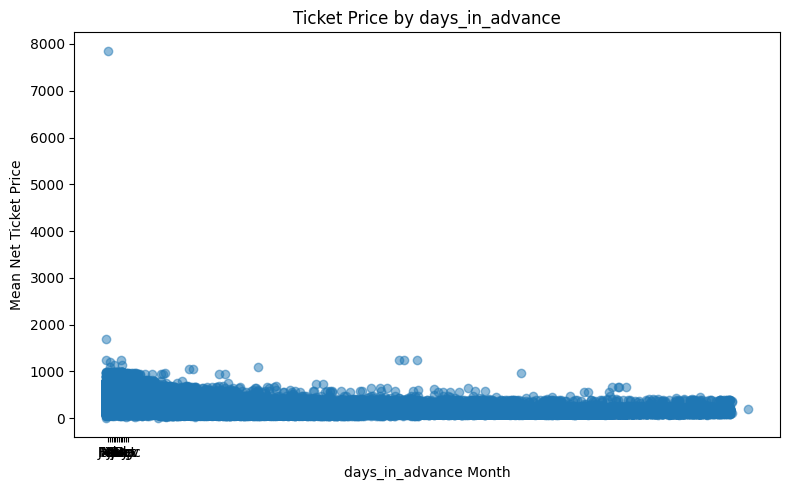

In [11]:
# Scatterplot of mean_net_ticket_price by Purchase_Month
plt.figure(figsize=(8, 5))
plt.scatter(df["days_in_advance"], df["mean_net_ticket_price"], alpha=0.5)
plt.xlabel("days_in_advance Month")
plt.ylabel("Mean Net Ticket Price")
plt.title("Ticket Price by days_in_advance")
plt.xticks(ticks=range(1,13), labels=[calendar.month_abbr[m] for m in range(1,13)])
plt.tight_layout()
plt.show()

In [12]:
# Check Outliers 
# Rank by mean_net_ticket_price and print top 10 and bottom 10
df_sorted = df.sort_values("mean_net_ticket_price", ascending=False)

print("\nTop 10 records by mean_net_ticket_price:")
print(df_sorted.head(10))

print("\nBottom 10 records by mean_net_ticket_price:")
print(df_sorted.tail(10))

Q1 = df["ln_P"].quantile(0.25)
Q3 = df["ln_P"].quantile(0.75)
IQR = Q3 - Q1
print("\nQ1 data")
print("Q1:", Q1)
print("\nQ3 data")
print("Q3:", Q3)
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("\n Lower bound")
print("Lower bound:", lower_bound)
print("\n Upper bound")
print("Upper bound:", upper_bound)
outliers = df[(df["ln_P"] < lower_bound) | (df["ln_P"] > upper_bound)]
print("Number of outliers:", len(outliers))
print("\nOutlier records:")
print(outliers[["mean_net_ticket_price", "ln_P"]])


Top 10 records by mean_net_ticket_price:
        num_seats_total  mean_net_ticket_price  Dept_Date Purchase_Date  \
45561                 1            7855.766106 2018-10-23    2018-10-22   
46935                 1            1701.558448 2018-07-02    2018-07-02   
179                   1            1251.668559 2019-05-09    2018-11-21   
209079                1            1251.188608 2018-11-19    2018-11-19   
185                   1            1249.254663 2019-10-24    2019-05-11   
159                   1            1249.061940 2019-05-16    2018-11-21   
32963                 1            1238.598690 2019-01-24    2019-01-16   
205051                1            1194.557862 2019-02-21    2019-02-19   
200888                1            1140.637353 2018-10-12    2018-10-08   
190201                1            1130.395309 2018-08-23    2018-08-14   

       Train_Number_All  Culmulative_sales  isNormCabin  isReturn  isOneway  \
45561                 D                  1           

In [13]:
# Remove 3 outliers by mean_net_ticket_price values
# Remove records with mean_net_ticket_price > 7855 or < 10
df = df[(df["mean_net_ticket_price"] <= 7855) & (df["mean_net_ticket_price"] >= 10)]
print("Removed records with extreme prices. Data shape:", df.shape)


# Check whether weekend or month has stronger effect on demand
# Based on the adjusted R2, month has a stronger effect than weekend

# Baseline with weekend only
m1 = smf.ols("num_seats_total ~ mean_net_ticket_price + dep_is_weekend", data=df).fit()
print(m1.rsquared_adj)

# Baseline with month only
m2 = smf.ols("num_seats_total ~ mean_net_ticket_price + C(Dept_Month)", data=df).fit()
print(m2.rsquared_adj)

# Both together
m3 = smf.ols("num_seats_total ~ mean_net_ticket_price + dep_is_weekend + C(Dept_Month)", data=df).fit()
print(m3.rsquared_adj)

# Check correlations - results show that the 2 variables are not highly correlated

print(pd.crosstab(df["isReturn"], df["isOneway"]))
print(df[["isReturn","isOneway"]].corr())

# Create combined ticket type variable to see if there are clusters, and for ease of interpretation given that there are some observations with overlaps between IsReturn and IsOneway
# IsReturn and IsOneway are not mutually exclusive
def ticket_type(row):
    r, o = int(row["isReturn"]), int(row["isOneway"])
    if r == 1 and o == 0: return "Return_only"
    if r == 0 and o == 1: return "Oneway_only"
    if r == 1 and o == 1: return "Both"
    return "Neither"

df["ticket_type"] = df[["isReturn","isOneway"]].apply(ticket_type, axis=1)


# Check whether using ticket_type or separate dummies is better
# Based on the adjusted R2, using ticket_type is slightly better. Ok to use ticket_type since it is easier to interpret, and doesnt make the model worse
m4 = smf.ols("ln_Q ~ ln_P + days_in_advance + isNormCabin + isReturn + isOneway + C(Dept_Month) + C(Customer_Cat) + C(Train_Number_All)", data=df).fit(cov_type="cluster", cov_kwds={"groups": df["Train_Number_All"]})

m5 = smf.ols("ln_Q ~ ln_P + days_in_advance + isNormCabin + C(ticket_type) + C(Dept_Month) + C(Customer_Cat) + C(Train_Number_All)", data=df).fit(cov_type="cluster", cov_kwds={"groups": df["Train_Number_All"]})

print("Adj R² with separate dummies:", m4.rsquared_adj)
print("Adj R² with ticket_type:", m5.rsquared_adj)


Removed records with extreme prices. Data shape: (209694, 21)
0.037810439666679185
0.056323147528900996
0.05632778748918377
isOneway      0      1
isReturn              
0         91520  17481
1         92410   8283
          isReturn  isOneway
isReturn  1.000000 -0.118882
isOneway -0.118882  1.000000
Adj R² with separate dummies: 0.14647366191057976
Adj R² with ticket_type: 0.14708567247036364


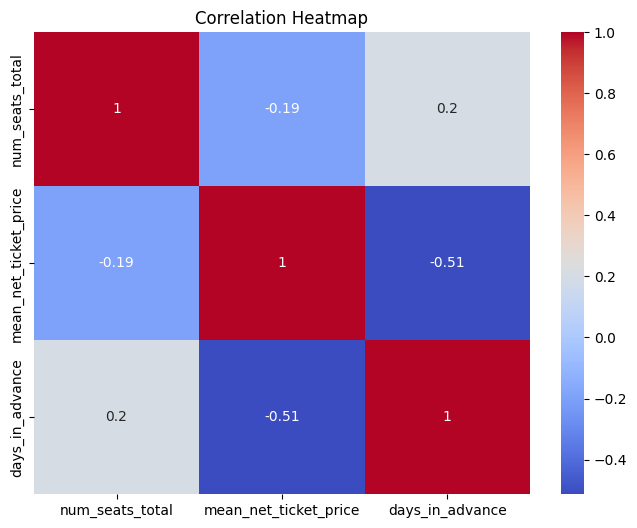

In [14]:

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['num_seats_total', 'mean_net_ticket_price', 'days_in_advance']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Convert Train_Number_All to integer codes for clustering
df["Train_Number_code"] = df["Train_Number_All"].astype("category").cat.codes

# Convert Dept_Date to integer codes for clustering
df["Dept_Date_code"] = df["Dept_Date"].astype("category").cat.codes


In [15]:
#Run baseline OLS 
# reference from stackoverflow

# --- Ensure ticket_type has "Return_only" as baseline ---
df["ticket_type"] = pd.Categorical(
    df["ticket_type"],
    categories=["Return_only","Oneway_only","Both","Neither"],
    ordered=False
)

# Levels regression
wdf = df[[
    "num_seats_total","mean_net_ticket_price","days_in_advance",
    "isNormCabin","ticket_type",
    "Customer_Cat","Train_Number_All","Dept_Date"
]].dropna()

# Add month variable
wdf["Dept_month"] = wdf["Dept_Date"].dt.month
wdf["isNormCabin"] = wdf["isNormCabin"].astype(int)

lin_formula = """
num_seats_total ~ mean_net_ticket_price + days_in_advance
                 + isNormCabin
                 + C(ticket_type)
                 + C(Dept_month) + C(Customer_Cat) + C(Train_Number_All)
"""

lin_fit = smf.ols(lin_formula, data=wdf).fit(cov_type="HC3")

print("\n=== Levels OLS (with Month FE, ticket_type baseline=Return_only) ===")
print(lin_fit.summary())

# Log–log test

wdf2 = df[[
    "ln_Q","ln_P","days_in_advance",
    "isNormCabin","ticket_type",
    "Customer_Cat","Train_Number_All","Dept_Date"
]].dropna()

# Add month variable
wdf2["Dept_month"] = wdf2["Dept_Date"].dt.month
wdf2["isNormCabin"] = wdf2["isNormCabin"].astype(int)

log_formula = """
ln_Q ~ ln_P + days_in_advance
        + isNormCabin
        + C(ticket_type)
        + C(Dept_month) + C(Customer_Cat) + C(Train_Number_All)
"""

log_fit = smf.ols(log_formula, data=wdf2).fit(cov_type="HC3")

print("\n=== Log–log OLS (with Month FE, ticket_type baseline=Return_only) ===")
print(log_fit.summary())

# Sanity check - that we are not losing too many rows to NA ==> looks ok. Numbers before and after are same.
print("Rows before:", len(df))
print("Rows in wdf (levels):", len(wdf))
print("Rows in wdf2 (logs):", len(wdf2))
missing_tbl.sort_values("pct_missing").head(10)  # which cols are killing rows?



=== Levels OLS (with Month FE, ticket_type baseline=Return_only) ===
                            OLS Regression Results                            
Dep. Variable:        num_seats_total   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     868.9
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:05:51   Log-Likelihood:            -4.4075e+05
No. Observations:              209694   AIC:                         8.816e+05
Df Residuals:                  209661   BIC:                         8.819e+05
Df Model:                          32                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

,column,missing,pct_missing
0,num_seats_total,0,0.0
1,mean_net_ticket_price,0,0.0
2,Dept_Date,0,0.0
3,Purchase_Date,0,0.0
4,Train_Number_All,0,0.0
5,Culmulative_sales,0,0.0
6,isNormCabin,0,0.0
7,isReturn,0,0.0
8,isOneway,0,0.0
9,Customer_Cat,0,0.0


For How to interpret Wu-Hausman test:

Null hypothesis (H₀): OLS is consistent (price is not endogenous)
Alternative (H₁): OLS is biased, need IV (price is endogenous)

P-value	Conclusion	What to use
p < 0.05	Reject H₀ → Price is endogenous	✅ Use IV/2SLS
p > 0.05	Fail to reject H₀ → Price is exogenous	Use OLS (IV not needed)

In [6]:
# 2SLS
from linearmodels.iv import IV2SLS
# Levels regression
# Working frame
wdf = df[[
    "num_seats_total","mean_net_ticket_price","days_in_advance",
    "isNormCabin","ticket_type",
    "Customer_Cat","Train_Number_All","Dept_Date"
]].dropna()
wdf["Dept_month"]  = wdf["Dept_Date"].dt.month
wdf["isNormCabin"] = wdf["isNormCabin"].astype(int)

# 2SLS formula: instrument mean_net_ticket_price with days_in_advance
iv_formula_lvl = """
num_seats_total
 ~ 1 + isNormCabin
   + C(ticket_type) + C(Dept_month) + C(Customer_Cat) + C(Train_Number_All)
[ mean_net_ticket_price ~ days_in_advance ]
"""

# """
# dependent_var ~ exog_var1 + exog_var2
# [endogenous_var ~ instrument1 + instrument2 + instrument3]
# """

iv_fit_lvl = IV2SLS.from_formula(iv_formula_lvl, data=wdf).fit(cov_type="robust")
print("\n=== 2SLS (LEVELS) ===")
print(iv_fit_lvl.summary)

# Diagnostics you’ll cite
print("\nFirst-stage (price on instrument):")
print(iv_fit_lvl.first_stage)
print("\nEndogeneity tests (Wu-Hausman):")
print(iv_fit_lvl.wu_hausman)

# Log–log test
# Working frame
wdf2 = df[[
    "ln_Q","ln_P","days_in_advance",
    "isNormCabin","ticket_type",
    "Customer_Cat","Train_Number_All","Dept_Date"
]].dropna()
wdf2["Dept_month"]  = wdf2["Dept_Date"].dt.month
wdf2["isNormCabin"] = wdf2["isNormCabin"].astype(int)

# 2SLS formula: instrument ln_P with days_in_advance
iv_formula_log = """
ln_Q
 ~ 1 + isNormCabin
   + C(ticket_type) + C(Dept_month) + C(Customer_Cat) + C(Train_Number_All)
[ ln_P ~ days_in_advance ]
"""

iv_fit_log = IV2SLS.from_formula(iv_formula_log, data=wdf2).fit(cov_type="robust")

print("\n=== 2SLS (LOG-LOG) ===")
print(iv_fit_log.summary)

# Elasticity (coefficient on ln_P)
print("\nPrice elasticity (2SLS):", iv_fit_log.params["ln_P"])

# Diagnostics
print("\nFirst-stage (ln_P on instrument):")
print(iv_fit_log.first_stage)
print("\nEndogeneity tests (Wu-Hausman):")
print(iv_fit_log.wu_hausman)



KeyError: "['days_in_advance', 'ticket_type'] not in index"